**Clean the Dataset**

In [1]:
import pandas as pd
df_clean = pd.read_csv('original.csv')

In [2]:
df_clean.head()

,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [3]:
df_clean.isna().sum()

index              0
stream             0
Zscore             0
district_rank      0
island_rank        0
al_year            0
sub1               0
sub1_r             0
sub2               0
sub2_r             0
sub3               0
sub3_r             0
cgt_r              0
ge_r               0
syllabus           0
birth_day          0
birth_month        0
birth_year         0
gender           888
dtype: int64

In [4]:
df_clean= df_clean.drop(columns=['district_rank', 'island_rank'])
display(df_clean.head())

,index,stream,Zscore,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [5]:
import numpy as np
df_cleaned = df_clean.replace('-', np.nan)
missing_values_count = df_cleaned.isnull().sum()
print("Number of missing values per column (represented as '-'):")
print(missing_values_count[missing_values_count > 0])

Number of missing values per column (represented as '-'):
stream    142026
Zscore     99788
gender       888
dtype: int64


In [6]:
import pandas as pd

# 1. Filter out rows from df_cleaned where the 'stream' column is not null.
df_stream_not_null = df_cleaned[df_cleaned['stream'].notna()].copy()

# 2. Create an empty dictionary to store the mapping.
subject_to_stream_map = {}

# 3. For each of the subject columns ('sub1', 'sub2', 'sub3')
subject_columns = ['sub1', 'sub2', 'sub3']

# Get all unique subjects from all subject columns where stream is not null
all_subjects = pd.concat([df_stream_not_null[col].dropna() for col in subject_columns]).unique()

# 4. For each unique subject, find the most frequent 'stream' associated with it.
for subject in all_subjects:
    # Find all rows where the current subject appears in any of the subject columns
    # and the 'stream' is not null.
    relevant_rows = df_stream_not_null[
        (df_stream_not_null['sub1'] == subject) |
        (df_stream_not_null['sub2'] == subject) |
        (df_stream_not_null['sub3'] == subject)
    ]

    if not relevant_rows.empty:
        # Get the mode (most frequent) of the 'stream' for these relevant rows.
        # Drop NaN from stream column before calculating mode
        stream_modes = relevant_rows['stream'].dropna().mode()
        if not stream_modes.empty:
            # Take the first mode if there are multiple (e.g., tie).
            most_frequent_stream = stream_modes[0]
            # 5. Add this subject-stream pair to the `subject_to_stream_map` dictionary.
            subject_to_stream_map[subject] = most_frequent_stream

print("Generated subject-to-stream map (first 10 entries):\n")
# Displaying the first few entries of the map
for i, (subject, stream) in enumerate(subject_to_stream_map.items()):
    if i >= 10:
        break
    print(f"{subject}: {stream}")
print(f"\nTotal subjects mapped: {len(subject_to_stream_map)}")

Generated subject-to-stream map (first 10 entries):

POLITICAL SCIENCE: ARTS
ECONOMICS: COMMERCE
PHYSICS: BIOLOGICAL SCIENCE
GEOGRAPHY: ARTS
COMMUNICATION & MEDIA STUDIES: ARTS
AGRICULTURAL SCIENCE: BIOSYSTEMS TECHNOLOGY
LOGIC & SCIENTIFIC METHOD: ARTS
HISTORY OF INDIA: ARTS
INFORMATION & COMMUNICATION TECHNOLOGY: ENGINEERING TECHNOLOGY
CHEMISTRY: BIOLOGICAL SCIENCE

Total subjects mapped: 61


In [7]:
def impute_stream(row):
    if pd.isna(row['stream']):
        for sub_col in ['sub1', 'sub2', 'sub3']:
            subject = row[sub_col]
            if pd.notna(subject) and subject in subject_to_stream_map:
                return subject_to_stream_map[subject]
    return row['stream']

df_cleaned['stream'] = df_cleaned.apply(impute_stream, axis=1)

print("Missing values in 'stream' column after imputation:")
print(df_cleaned['stream'].isnull().sum())

Missing values in 'stream' column after imputation:
0


In [8]:
print(df_cleaned.isna().sum())

index              0
stream             0
Zscore         99788
al_year            0
sub1               0
sub1_r             0
sub2               0
sub2_r             0
sub3               0
sub3_r             0
cgt_r              0
ge_r               0
syllabus           0
birth_day          0
birth_month        0
birth_year         0
gender           888
dtype: int64


In [9]:
df_cleaned = df_cleaned.dropna()
print("Shape of DataFrame after dropping rows with any null values:", df_cleaned.shape)
print("\nMissing values after dropping rows:")
print(df_cleaned.isna().sum())

Shape of DataFrame after dropping rows with any null values: (214009, 17)

Missing values after dropping rows:
index          0
stream         0
Zscore         0
al_year        0
sub1           0
sub1_r         0
sub2           0
sub2_r         0
sub3           0
sub3_r         0
cgt_r          0
ge_r           0
syllabus       0
birth_day      0
birth_month    0
birth_year     0
gender         0
dtype: int64


In [10]:

# Save the cleaned DataFrame to a CSV file
df_cleaned.to_csv('cleaned_data.csv', index=False)

**Taking the Stratified Sample**

In [11]:
import pandas as pd
df_s  = pd.read_csv('cleaned_data.csv')

In [12]:
stratum_counts = df_s.groupby(['stream', 'syllabus']).size()
print("Population counts for each stream and syllabus combination:\n", stratum_counts)

Population counts for each stream and syllabus combination:
 stream                  syllabus
ARTS                    new         83308
                        old          5770
BIOLOGICAL SCIENCE      new         28580
                        old          6079
BIOSYSTEMS TECHNOLOGY   new          9814
                        old           596
COMMERCE                new         40315
                        old           895
ENGINEERING TECHNOLOGY  new         16772
                        old           611
NON                     new          1989
                        old           317
PHYSICAL SCIENCE        new         17535
                        old          1428
dtype: int64


In [13]:
sample_size = 383
total_population_stratified = stratum_counts.sum()
stratum_sample_sizes = (
    (stratum_counts / total_population_stratified) * sample_size
).round().astype(int)

print("Calculated sample sizes for each stream and syllabus stratum:")
print(stratum_sample_sizes)

Calculated sample sizes for each stream and syllabus stratum:
stream                  syllabus
ARTS                    new         149
                        old          10
BIOLOGICAL SCIENCE      new          51
                        old          11
BIOSYSTEMS TECHNOLOGY   new          18
                        old           1
COMMERCE                new          72
                        old           2
ENGINEERING TECHNOLOGY  new          30
                        old           1
NON                     new           4
                        old           1
PHYSICAL SCIENCE        new          31
                        old           3
dtype: int64


In [14]:
import numpy as np
np.random.seed(42) # for reproducibility

sample_df_stratified_stream_syllabus = (
    df_s.groupby(['stream', 'syllabus'], group_keys=False)
    .apply(lambda x: x.sample(n=stratum_sample_sizes[x.name], random_state=42))
)

print("Shape of the stratified sample DataFrame:", sample_df_stratified_stream_syllabus.shape)
print("Value counts of 'stream' and 'syllabus' in the stratified sample:")
print(sample_df_stratified_stream_syllabus.groupby(['stream', 'syllabus']).size())

Shape of the stratified sample DataFrame: (384, 17)
Value counts of 'stream' and 'syllabus' in the stratified sample:
stream                  syllabus
ARTS                    new         149
                        old          10
BIOLOGICAL SCIENCE      new          51
                        old          11
BIOSYSTEMS TECHNOLOGY   new          18
                        old           1
COMMERCE                new          72
                        old           2
ENGINEERING TECHNOLOGY  new          30
                        old           1
NON                     new           4
                        old           1
PHYSICAL SCIENCE        new          31
                        old           3
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_16380\3236794223.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=stratum_sample_sizes[x.name], random_state=42))


In [15]:
sample_df_stratified_stream_syllabus.to_csv("final_stratified_sample_by_stream_syllabus.csv", index=False)

**EDA**

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv('final_stratified_sample.csv')

In [17]:
print(df.groupby(['stream', 'syllabus']).size())

stream                  syllabus
ARTS                    new         145
                        old          10
BIOLOGICAL SCIENCE      new          54
                        old          10
BIOSYSTEMS TECHNOLOGY   new          17
                        old           1
COMMERCE                new          78
                        old           1
ENGINEERING TECHNOLOGY  new          30
                        old           1
PHYSICAL SCIENCE        new          34
                        old           2
dtype: int64


In [18]:
df.head()

,index,stream,Zscore,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,197401,ARTS,-0.5977,2020,POLITICAL SCIENCE,F,BUDDHIST CIVILIZATION,S,SINHALA,S,036,F,new,16,August,1989,male
1,117518,ARTS,0.5419,2020,POLITICAL SCIENCE,C,BUDDHIST CIVILIZATION,C,SINHALA,B,044,F,new,12,March,2001,female
2,136408,ARTS,1.1139,2020,GEOGRAPHY,B,POLITICAL SCIENCE,B,ARABIC,A,048,C,new,31,October,2000,female
3,250135,ARTS,-0.5008,2020,GEOGRAPHY,S,ART,S,SINHALA,S,032,F,new,12,January,2002,male
4,193614,ARTS,0.3237,2020,GEOGRAPHY,S,COMMUNICATION & MEDIA STUDIES,C,SINHALA,C,034,F,new,24,July,2000,female


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        383 non-null    int64  
 1   stream       383 non-null    object 
 2   Zscore       383 non-null    float64
 3   al_year      383 non-null    int64  
 4   sub1         383 non-null    object 
 5   sub1_r       383 non-null    object 
 6   sub2         383 non-null    object 
 7   sub2_r       383 non-null    object 
 8   sub3         383 non-null    object 
 9   sub3_r       383 non-null    object 
 10  cgt_r        383 non-null    object 
 11  ge_r         383 non-null    object 
 12  syllabus     383 non-null    object 
 13  birth_day    383 non-null    int64  
 14  birth_month  383 non-null    object 
 15  birth_year   383 non-null    int64  
 16  gender       383 non-null    object 
dtypes: float64(1), int64(4), object(12)
memory usage: 51.0+ KB


In [20]:
df['sub1_r'].value_counts()

sub1_r
S    155
C    113
B     50
F     37
A     28
Name: count, dtype: int64

In [21]:
df['sub2_r'].value_counts()

sub2_r
S    136
C    132
B     63
A     34
F     18
Name: count, dtype: int64

In [22]:
df['sub3_r'].value_counts()

sub3_r
S    125
C    122
B     82
A     39
F     15
Name: count, dtype: int64

In [23]:
df['age'] = df['al_year'] - df['birth_year']

In [24]:
df['marks_numeric'] = pd.to_numeric(df['cgt_r'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          383 non-null    int64  
 1   stream         383 non-null    object 
 2   Zscore         383 non-null    float64
 3   al_year        383 non-null    int64  
 4   sub1           383 non-null    object 
 5   sub1_r         383 non-null    object 
 6   sub2           383 non-null    object 
 7   sub2_r         383 non-null    object 
 8   sub3           383 non-null    object 
 9   sub3_r         383 non-null    object 
 10  cgt_r          383 non-null    object 
 11  ge_r           383 non-null    object 
 12  syllabus       383 non-null    object 
 13  birth_day      383 non-null    int64  
 14  birth_month    383 non-null    object 
 15  birth_year     383 non-null    int64  
 16  gender         383 non-null    object 
 17  age            383 non-null    int64  
 18  marks_nume

In [25]:
df['cgt_r'].describe()

count        383
unique        39
top       Absent
freq          59
Name: cgt_r, dtype: object

In [26]:
df[['cgt_r', 'marks_numeric']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cgt_r          383 non-null    object 
 1   marks_numeric  324 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.1+ KB


In [27]:
df['eligible_for_university_entrance'] = df.apply(lambda row: 'No' if 'F' in [row['sub1_r'], row['sub2_r'], row['sub3_r']] else 'Yes', axis=1)
display(df.head())


,index,stream,Zscore,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender,age,marks_numeric,eligible_for_university_entrance
0,197401,ARTS,-0.5977,2020,POLITICAL SCIENCE,F,BUDDHIST CIVILIZATION,S,SINHALA,S,036,F,new,16,August,1989,male,31,36.0,No
1,117518,ARTS,0.5419,2020,POLITICAL SCIENCE,C,BUDDHIST CIVILIZATION,C,SINHALA,B,044,F,new,12,March,2001,female,19,44.0,Yes
2,136408,ARTS,1.1139,2020,GEOGRAPHY,B,POLITICAL SCIENCE,B,ARABIC,A,048,C,new,31,October,2000,female,20,48.0,Yes
3,250135,ARTS,-0.5008,2020,GEOGRAPHY,S,ART,S,SINHALA,S,032,F,new,12,January,2002,male,18,32.0,Yes
4,193614,ARTS,0.3237,2020,GEOGRAPHY,S,COMMUNICATION & MEDIA STUDIES,C,SINHALA,C,034,F,new,24,July,2000,female,20,34.0,Yes


C:\Users\USER\AppData\Local\Temp\ipykernel_16380\1740515638.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_counts, x='gender', y='count', palette='viridis')


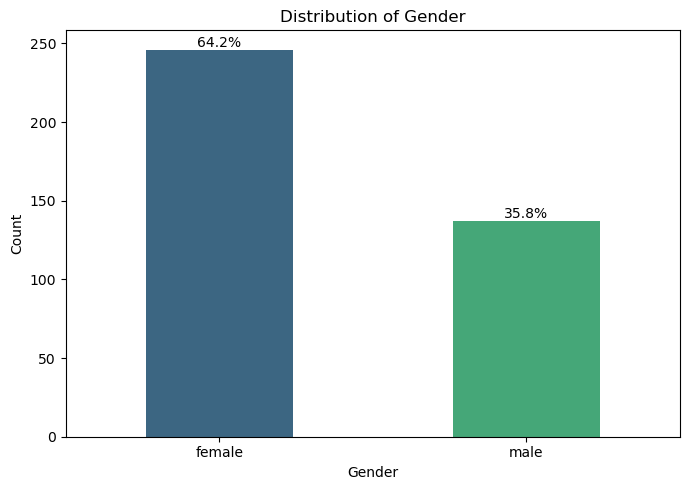

In [28]:
#barplot of gender
gender_counts = df['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=gender_counts, x='gender', y='count', palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()

total = gender_counts['count'].sum()

# Adjust bar width
shrink_factor = 0.6 # Adjust this value (e.g., 0.5 for half width, 0.8 for 80% width)
for p in ax.patches:
    current_width = p.get_width()
    new_width = current_width * shrink_factor
    p.set_width(new_width)
    p.set_x(p.get_x() + (current_width - new_width) / 2) # Re-center the bar

    # Annotate each bar with its percentage
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\3094183094.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=syllabus_counts, x='syllabus', y='count', palette='viridis')


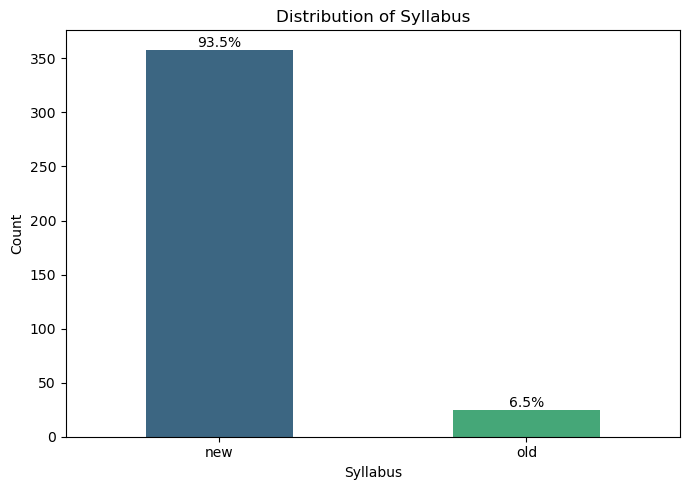

In [29]:
#bar plot of syllabus
syllabus_counts = df['syllabus'].value_counts().reset_index()
syllabus_counts.columns = ['syllabus', 'count']

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=syllabus_counts, x='syllabus', y='count', palette='viridis')
plt.title('Distribution of Syllabus')
plt.xlabel('Syllabus')
plt.ylabel('Count')
plt.tight_layout()

total = syllabus_counts['count'].sum()

# Adjust bar width
shrink_factor = 0.6 # Adjust this value (e.g., 0.5 for half width, 0.8 for 80% width)
for p in ax.patches:
    current_width = p.get_width()
    new_width = current_width * shrink_factor
    p.set_width(new_width)
    p.set_x(p.get_x() + (current_width - new_width) / 2) # Re-center the bar

    # Annotate each bar with its percentage
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

In [30]:
def categorize_marks(mark):
    # Handle 'absent' case
    if pd.isna(mark) or str(mark).strip().lower() == 'absent':
        return 'Absent'
    
    # Attempt to convert mark to numeric, handling potential errors
    try:
        mark = float(mark)
    except ValueError:
        return 'Invalid Input'

    if mark > 75:
        return 'A'
    elif mark >= 65 and mark <= 74:
        return 'B'
    elif mark >= 55 and mark <= 64:
        return 'C'
    elif mark >= 35 and mark <= 54:
        return 'S'
    elif mark <= 34:
        return 'F'
    else:
        return 'Invalid Input'

# Apply the categorization function to the 'cgt_r' column
df['Grade'] = df['cgt_r'].apply(categorize_marks)

# Display the head of the DataFrame to show the new 'Grade' column
print("DataFrame with 'Grade' column:")
display(df.head())

DataFrame with 'Grade' column:


,index,stream,Zscore,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,...,ge_r,syllabus,birth_day,birth_month,birth_year,gender,age,marks_numeric,eligible_for_university_entrance,Grade
0,197401,ARTS,-0.5977,2020,POLITICAL SCIENCE,F,BUDDHIST CIVILIZATION,S,SINHALA,S,...,F,new,16,August,1989,male,31,36.0,No,S
1,117518,ARTS,0.5419,2020,POLITICAL SCIENCE,C,BUDDHIST CIVILIZATION,C,SINHALA,B,...,F,new,12,March,2001,female,19,44.0,Yes,S
2,136408,ARTS,1.1139,2020,GEOGRAPHY,B,POLITICAL SCIENCE,B,ARABIC,A,...,C,new,31,October,2000,female,20,48.0,Yes,S
3,250135,ARTS,-0.5008,2020,GEOGRAPHY,S,ART,S,SINHALA,S,...,F,new,12,January,2002,male,18,32.0,Yes,F
4,193614,ARTS,0.3237,2020,GEOGRAPHY,S,COMMUNICATION & MEDIA STUDIES,C,SINHALA,C,...,F,new,24,July,2000,female,20,34.0,Yes,F


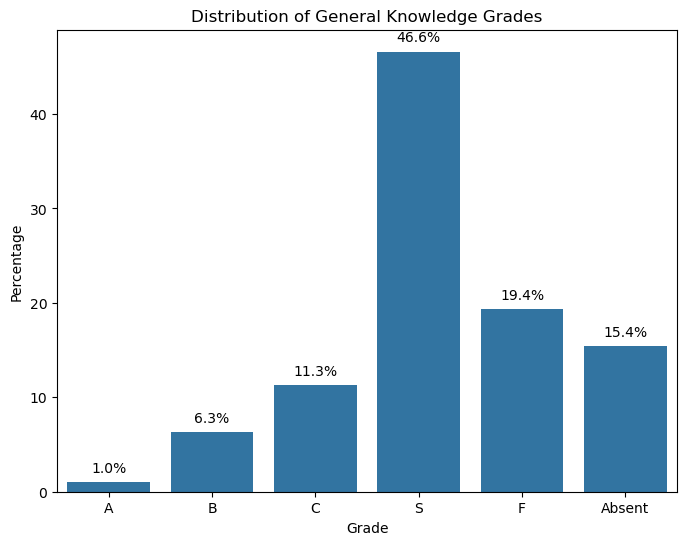

In [31]:
grade_order =['A','B','C','S','F','Absent']
df_filtered_grades=df[df['Grade']!='Invalid Input']
# Calculate percentages for the 'Grade' column
grade_percentages = df_filtered_grades['Grade'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
grade_percentages.columns = ['Grade', 'Percentage'] # Rename columns for clarity

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=grade_percentages, x='Grade', y='Percentage', order=grade_order)
plt.title('Distribution of General Knowledge Grades')
plt.xlabel('Grade')
plt.ylabel('Percentage')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

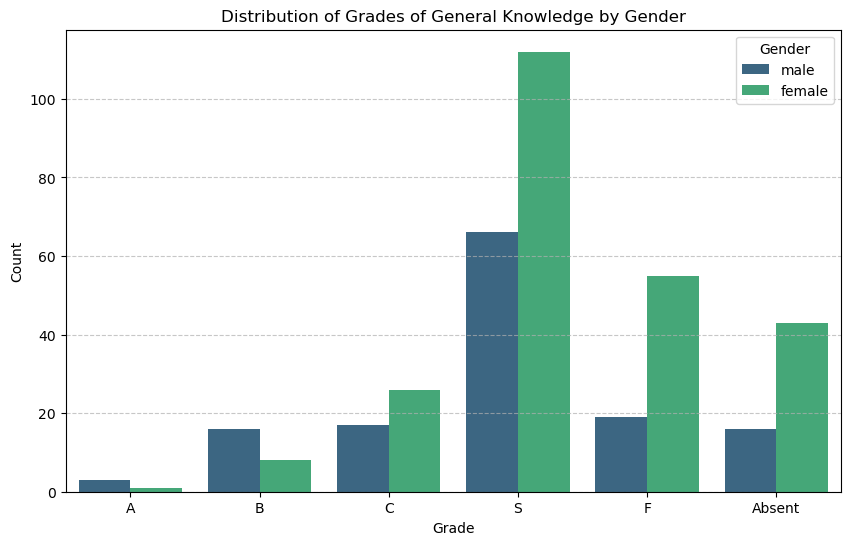

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Grade', hue='gender', order=grade_order, palette='viridis')
plt.title('Distribution of Grades of General Knowledge by Gender')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\2910161562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered_grades, x='Grade', y='Zscore', order=grade_order, palette='viridis')


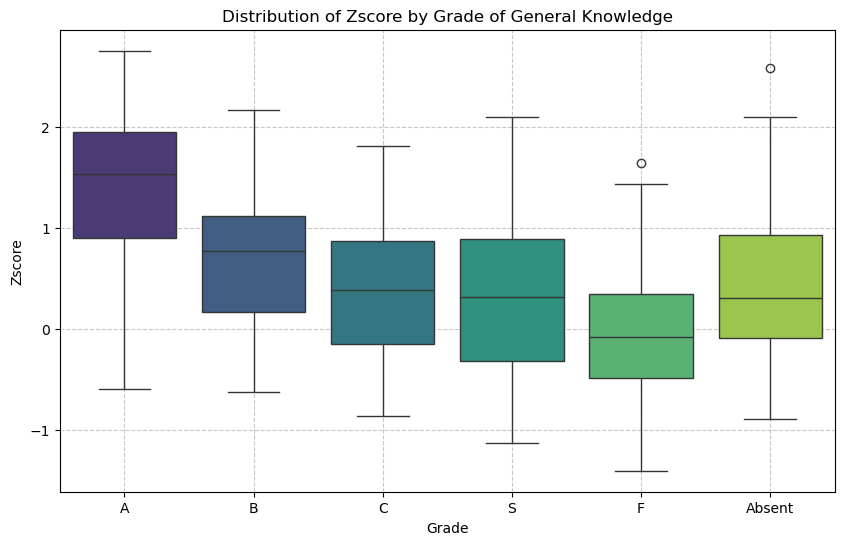

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered_grades, x='Grade', y='Zscore', order=grade_order, palette='viridis')
plt.title('Distribution of Zscore by Grade of General Knowledge')
plt.xlabel('Grade')
plt.ylabel('Zscore')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.savefig('ctg_r vs z')

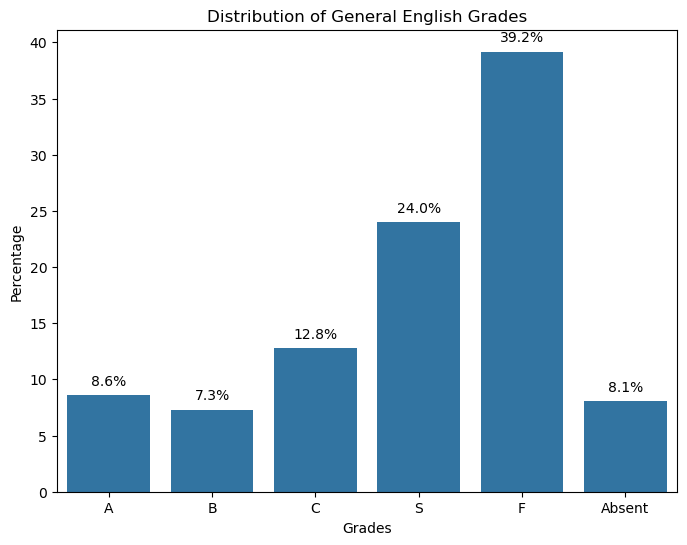

In [34]:
# Calculate percentages for 'ge_r' column
ge_r_percentages = df['ge_r'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
ge_r_percentages.columns = ['Grade', 'Percentage'] # Rename columns for clarity

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=ge_r_percentages, x='Grade', y='Percentage',order=grade_order)
plt.title('Distribution of General English Grades')
plt.xlabel('Grades')
plt.ylabel('Percentage')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\2812150191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ge_r', y='Zscore', order=grade_order, palette='viridis')


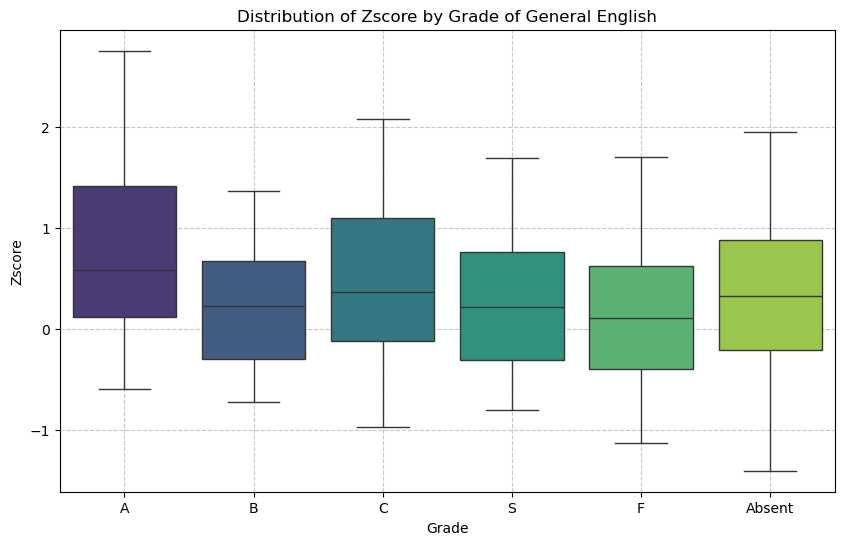

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ge_r', y='Zscore', order=grade_order, palette='viridis')
plt.title('Distribution of Zscore by Grade of General English')
plt.xlabel('Grade')
plt.ylabel('Zscore')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.savefig('ge_r vs z')

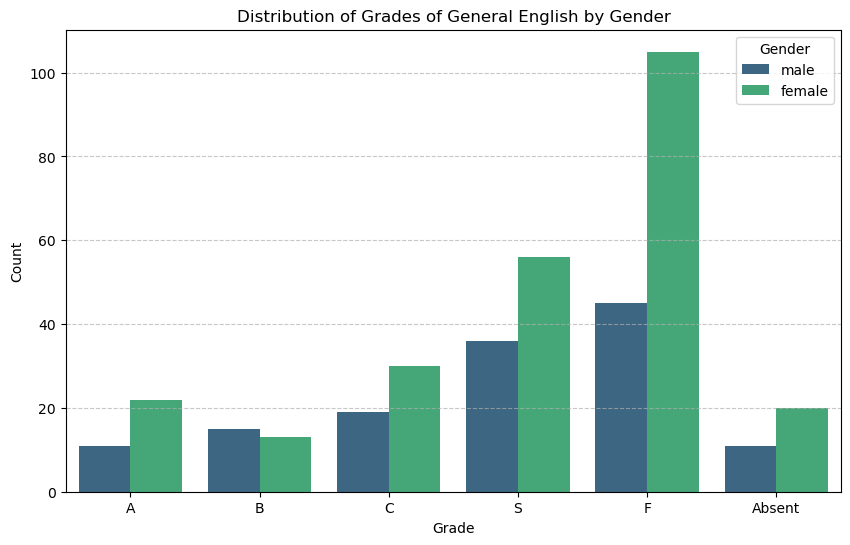

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ge_r', hue='gender', order=grade_order, palette='viridis')
plt.title('Distribution of Grades of General English by Gender')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
plt.savefig('ge_r vs g')

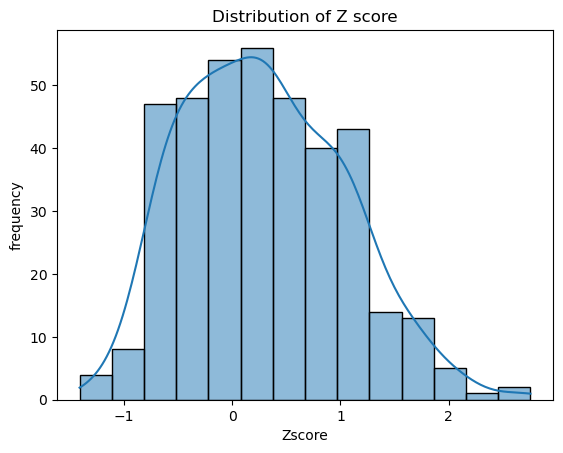

In [37]:
sns.histplot(df['Zscore'],kde=True)
plt.xlabel("Zscore")
plt.ylabel("frequency")
plt.title("Distribution of Z score")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\1923273152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


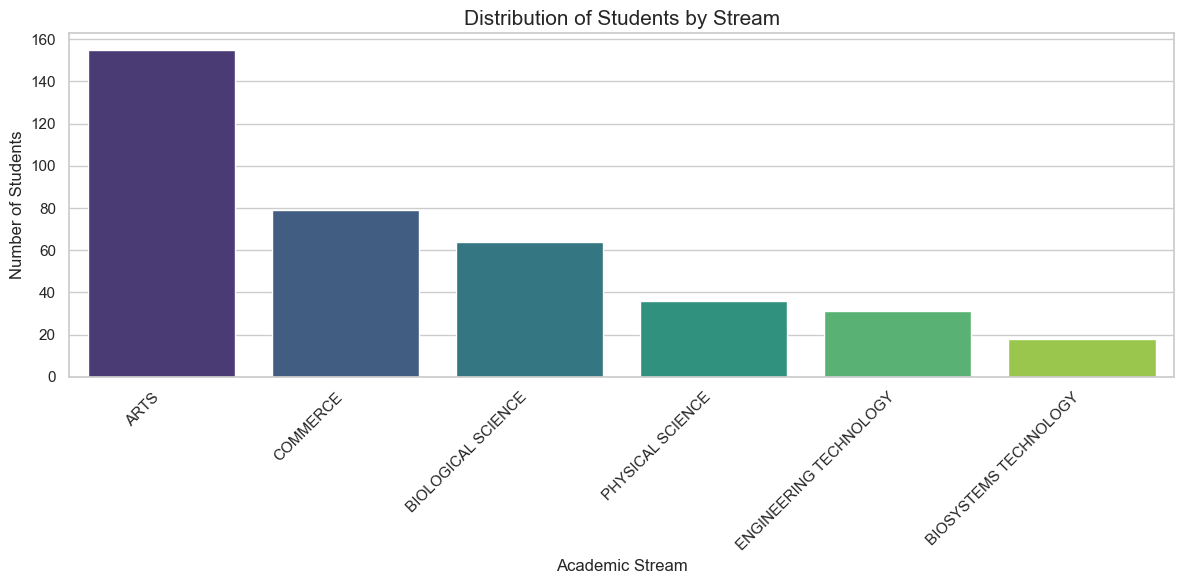

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
stream_order = df['stream'].value_counts().index
sns.countplot(
    data=df,
    x='stream',
    order=stream_order,
    palette='viridis'
)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Students by Stream', fontsize=15)
plt.xlabel('Academic Stream', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.tight_layout()
plt.savefig('stream_countplot.png')
plt.show()

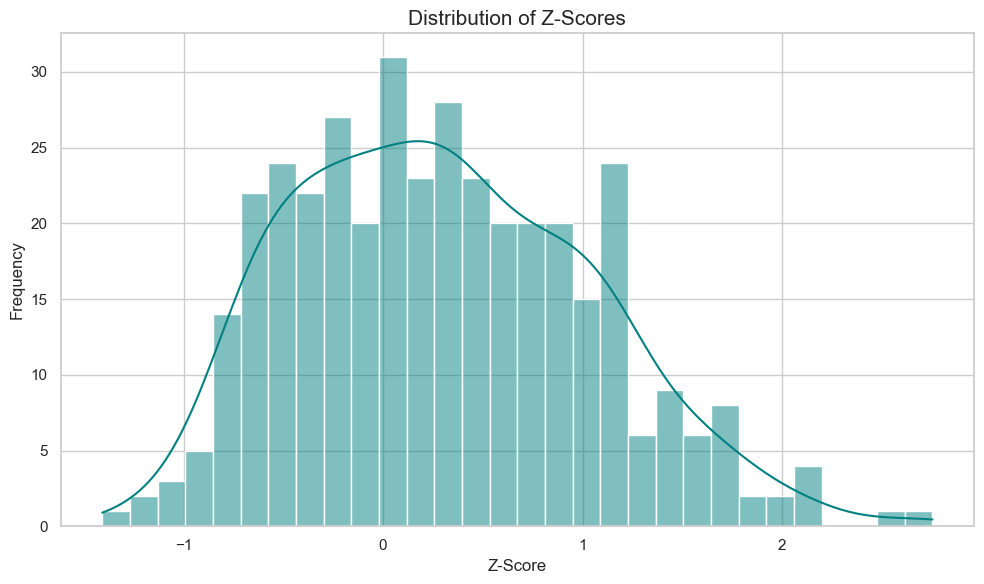

In [39]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Zscore', kde=True, color='teal', bins=30)
plt.title('Distribution of Z-Scores', fontsize=15)
plt.xlabel('Z-Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('zscore_histogram_kde.png')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_16380\3155714060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


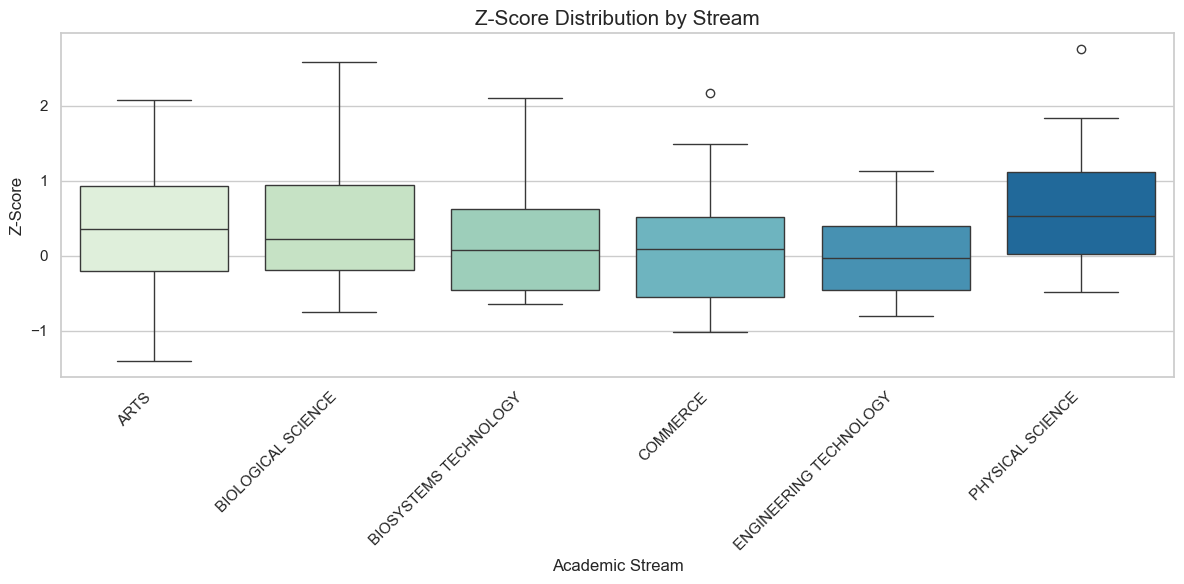

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='stream',
    y='Zscore',
    palette='GnBu'
)
plt.xticks(rotation=45, ha='right')
plt.title('Z-Score Distribution by Stream', fontsize=15)
plt.xlabel('Academic Stream', fontsize=12)
plt.ylabel('Z-Score', fontsize=12)
plt.tight_layout()
plt.savefig('zscore_boxplot_teal.png')
plt.show()

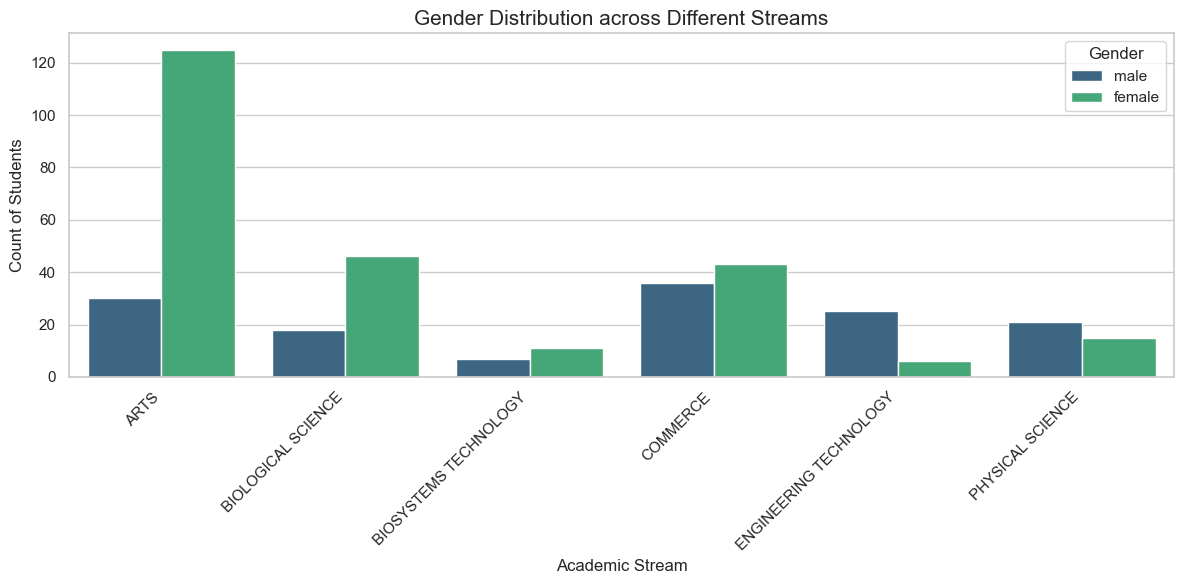

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='stream', hue='gender', palette='viridis')
plt.title('Gender Distribution across Different Streams', fontsize=15)
plt.xlabel('Academic Stream', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.xticks(rotation=45, ha='right') # Prevent label overlap
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()

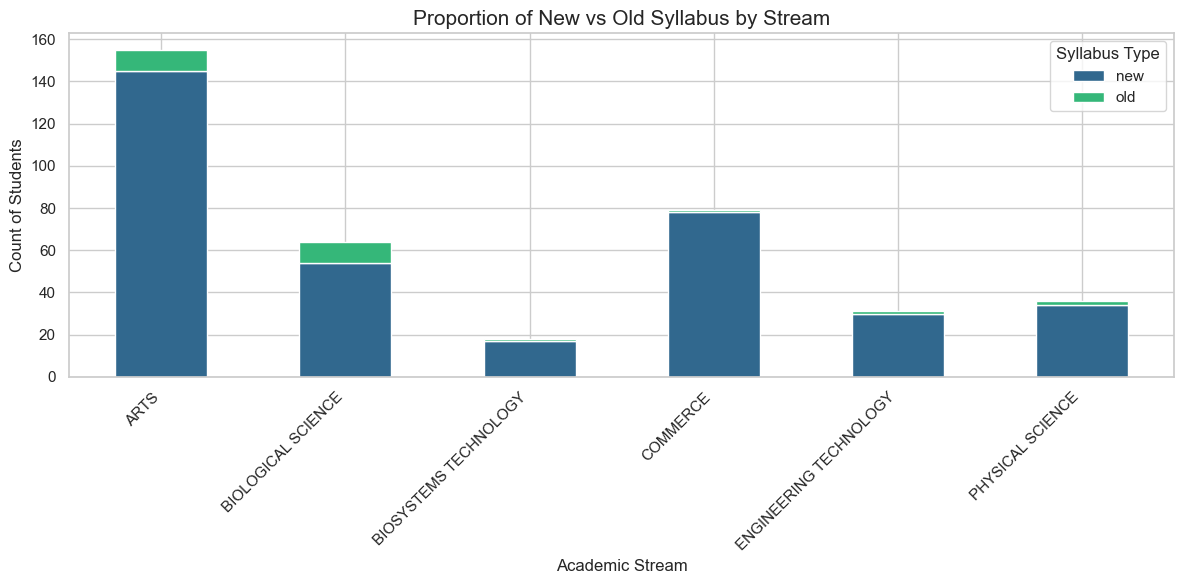

In [42]:
sns.set_theme(style="whitegrid")
syllabus_counts = pd.crosstab(df['stream'], df['syllabus'])
viridis_colors = sns.color_palette("viridis", 2)
ax = syllabus_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=viridis_colors
)
plt.title('Proportion of New vs Old Syllabus by Stream', fontsize=15)
plt.xlabel('Academic Stream', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.xticks(rotation=45, ha='right') # Prevent label overlap
plt.legend(title='Syllabus Type')
plt.tight_layout()
plt.savefig('syllabus_by_stream_viridis.png')
plt.show()

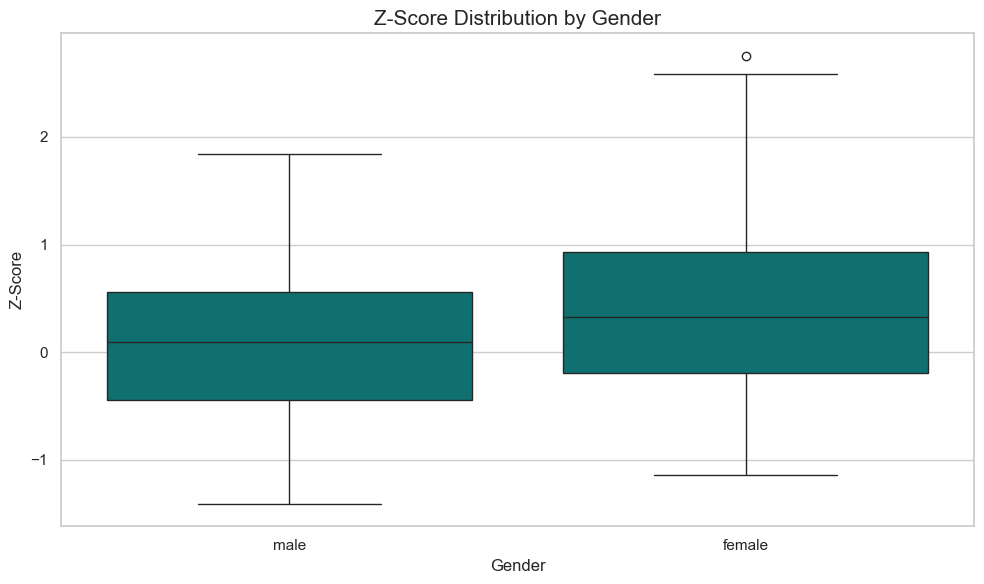

In [43]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='Zscore', color='teal')
plt.title('Z-Score Distribution by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Z-Score', fontsize=12)
plt.tight_layout()
plt.savefig('zscore_boxplot_gender.png')
plt.show()

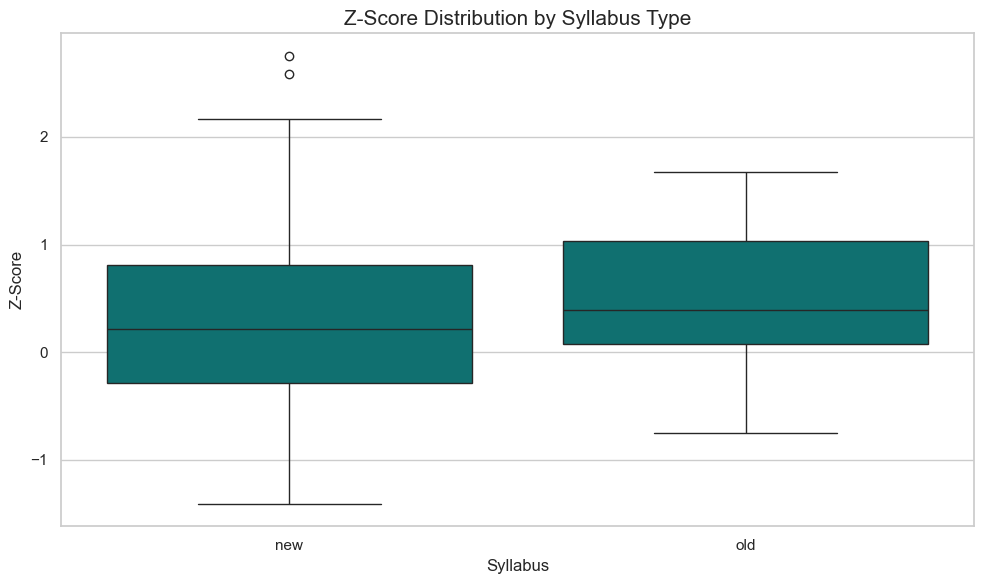

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='syllabus', y='Zscore', color='teal')
plt.title('Z-Score Distribution by Syllabus Type', fontsize=15)
plt.xlabel('Syllabus', fontsize=12)
plt.ylabel('Z-Score', fontsize=12)
plt.tight_layout()
plt.savefig('zscore_boxplot_syllabus.png')
plt.show()

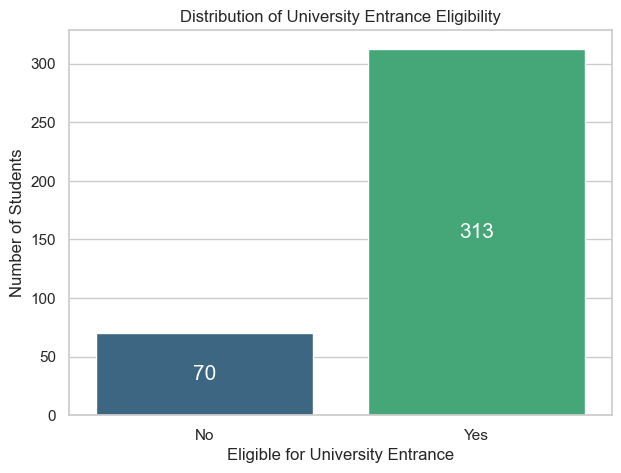

In [45]:


plt.figure(figsize=(7, 5))
ax = sns.countplot(x='eligible_for_university_entrance', data=df, palette='viridis', hue='eligible_for_university_entrance', legend=False)
plt.title('Distribution of University Entrance Eligibility')
plt.xlabel('Eligible for University Entrance')
plt.ylabel('Number of Students')

# Add value counts inside the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center',
                xytext=(0, 0),
                textcoords='offset points',
                color='white',
                fontsize=15)

plt.show()

In [46]:
eligibility_counts = df.groupby(['gender', 'eligible_for_university_entrance']).size().unstack(fill_value=0)
eligibility_proportions = eligibility_counts.div(eligibility_counts.sum(axis=1), axis=0)
display(eligibility_proportions)

eligible_for_university_entrance,No,Yes
gender,,
female,0.134146,0.865854
male,0.270073,0.729927


<Figure size 1200x800 with 0 Axes>

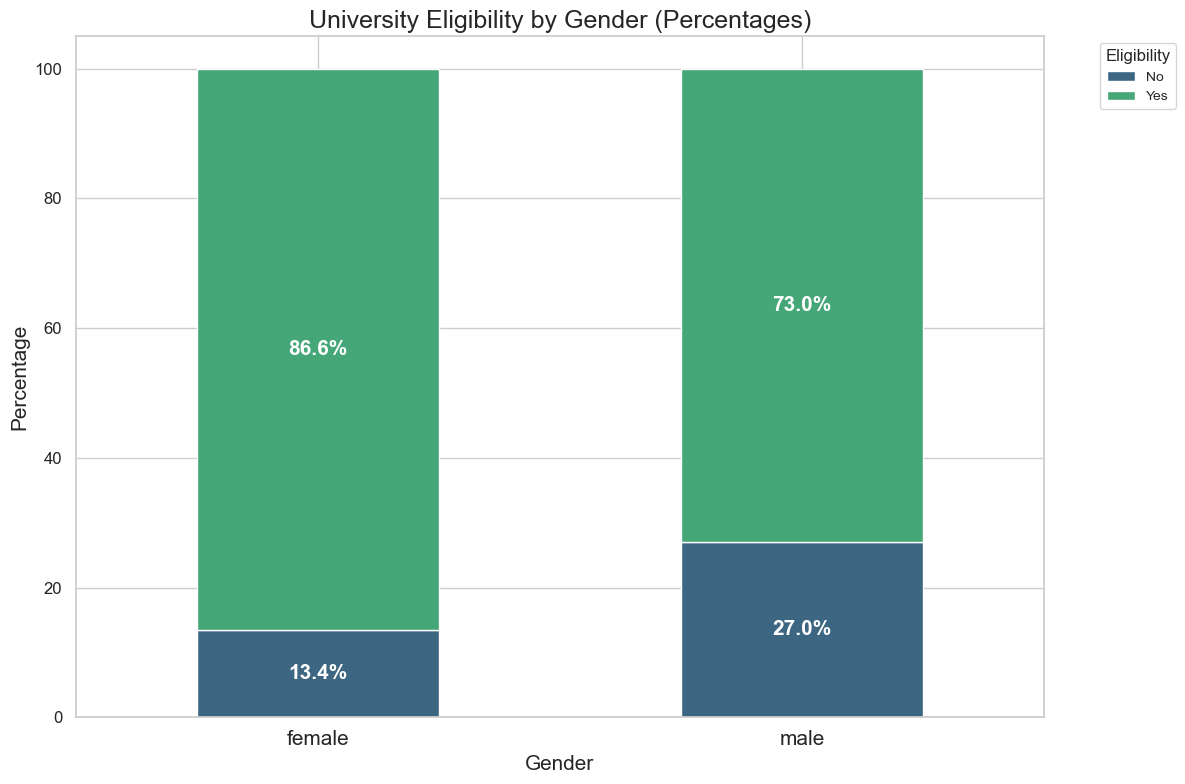

In [47]:
eligibility_gender_percentages = df.groupby('gender')['eligible_for_university_entrance'].value_counts(normalize=True).mul(100).unstack()
eligibility_gender_counts = df.groupby('gender')['eligible_for_university_entrance'].value_counts().unstack(fill_value=0) # Keep counts for reference, but won't be displayed

plt.figure(figsize=(12, 8))

# Correct the custom_palette_map to match the actual categories ('No' and 'Yes')
custom_palette_map = {'No': '#3c6682', 'Yes': '#45a778'}
colors_ordered = [custom_palette_map[col] for col in eligibility_gender_percentages.columns]

ax = eligibility_gender_percentages.plot(kind='bar', stacked=True, color=colors_ordered, figsize=(12, 8))
plt.title('University Eligibility by Gender (Percentages)', fontsize=18)
plt.xlabel('Gender', fontsize=15)
plt.ylabel('Percentage', fontsize=15)
plt.xticks(rotation=0, fontsize=15)
plt.yticks(fontsize=12)
plt.legend(title='Eligibility', bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize=12, fontsize=10)


# Annotate bars with percentages only
for i, gender in enumerate(eligibility_gender_percentages.index):
    current_height = 0
    for j, category in enumerate(eligibility_gender_percentages.columns):
        percentage = eligibility_gender_percentages.loc[gender, category]

        if percentage > 0:
            ax.text(x=i,
                    y=current_height + percentage / 2,
                    s=f'{percentage:.1f}%',
                    ha='center',
                    va='center',
                    color='white',
                    fontsize=15,
                    weight='bold')
        current_height += percentage

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

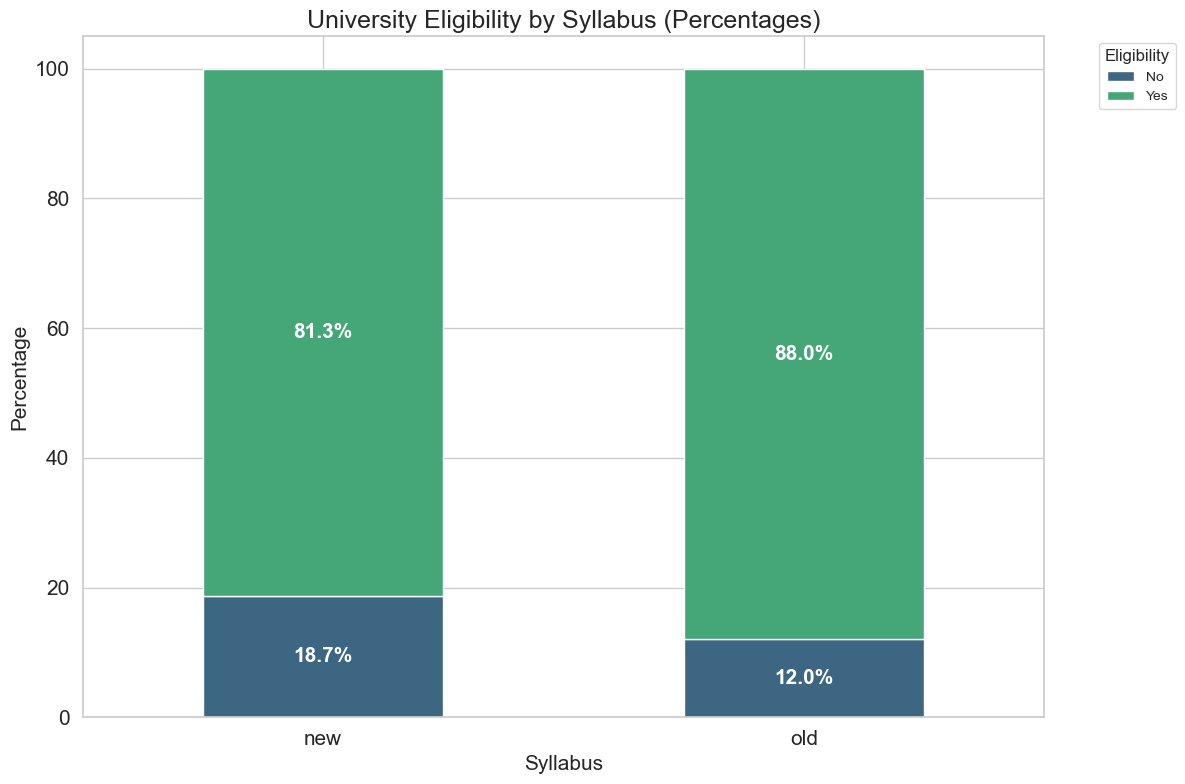

In [48]:
eligibility_syllabus_percentages = df.groupby('syllabus')['eligible_for_university_entrance'].value_counts(normalize=True).mul(100).unstack()
eligibility_syllabus_counts = df.groupby('syllabus')['eligible_for_university_entrance'].value_counts().unstack(fill_value=0) # Keep counts for reference, but won't be displayed

plt.figure(figsize=(12, 8))

# Correct the custom_palette_map to match the actual categories ('No' and 'Yes')
custom_palette_map = {'No': '#3c6682', 'Yes': '#45a778'}
colors_ordered = [custom_palette_map[col] for col in eligibility_syllabus_percentages.columns]

ax = eligibility_syllabus_percentages.plot(kind='bar', stacked=True, color=colors_ordered, figsize=(12, 8))
plt.title('University Eligibility by Syllabus (Percentages)', fontsize=18)
plt.xlabel('Syllabus', fontsize=15)
plt.ylabel('Percentage', fontsize=15)
plt.xticks(rotation=0, fontsize=15)
plt.yticks(fontsize=15)
plt.legend(title='Eligibility', bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize=12, fontsize=10)


# Annotate bars using the actual bar containers (robust method) with percentages only
for container, category in zip(ax.containers, eligibility_syllabus_percentages.columns):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=15,
                fontweight='bold'
            )

plt.tight_layout()
plt.show()

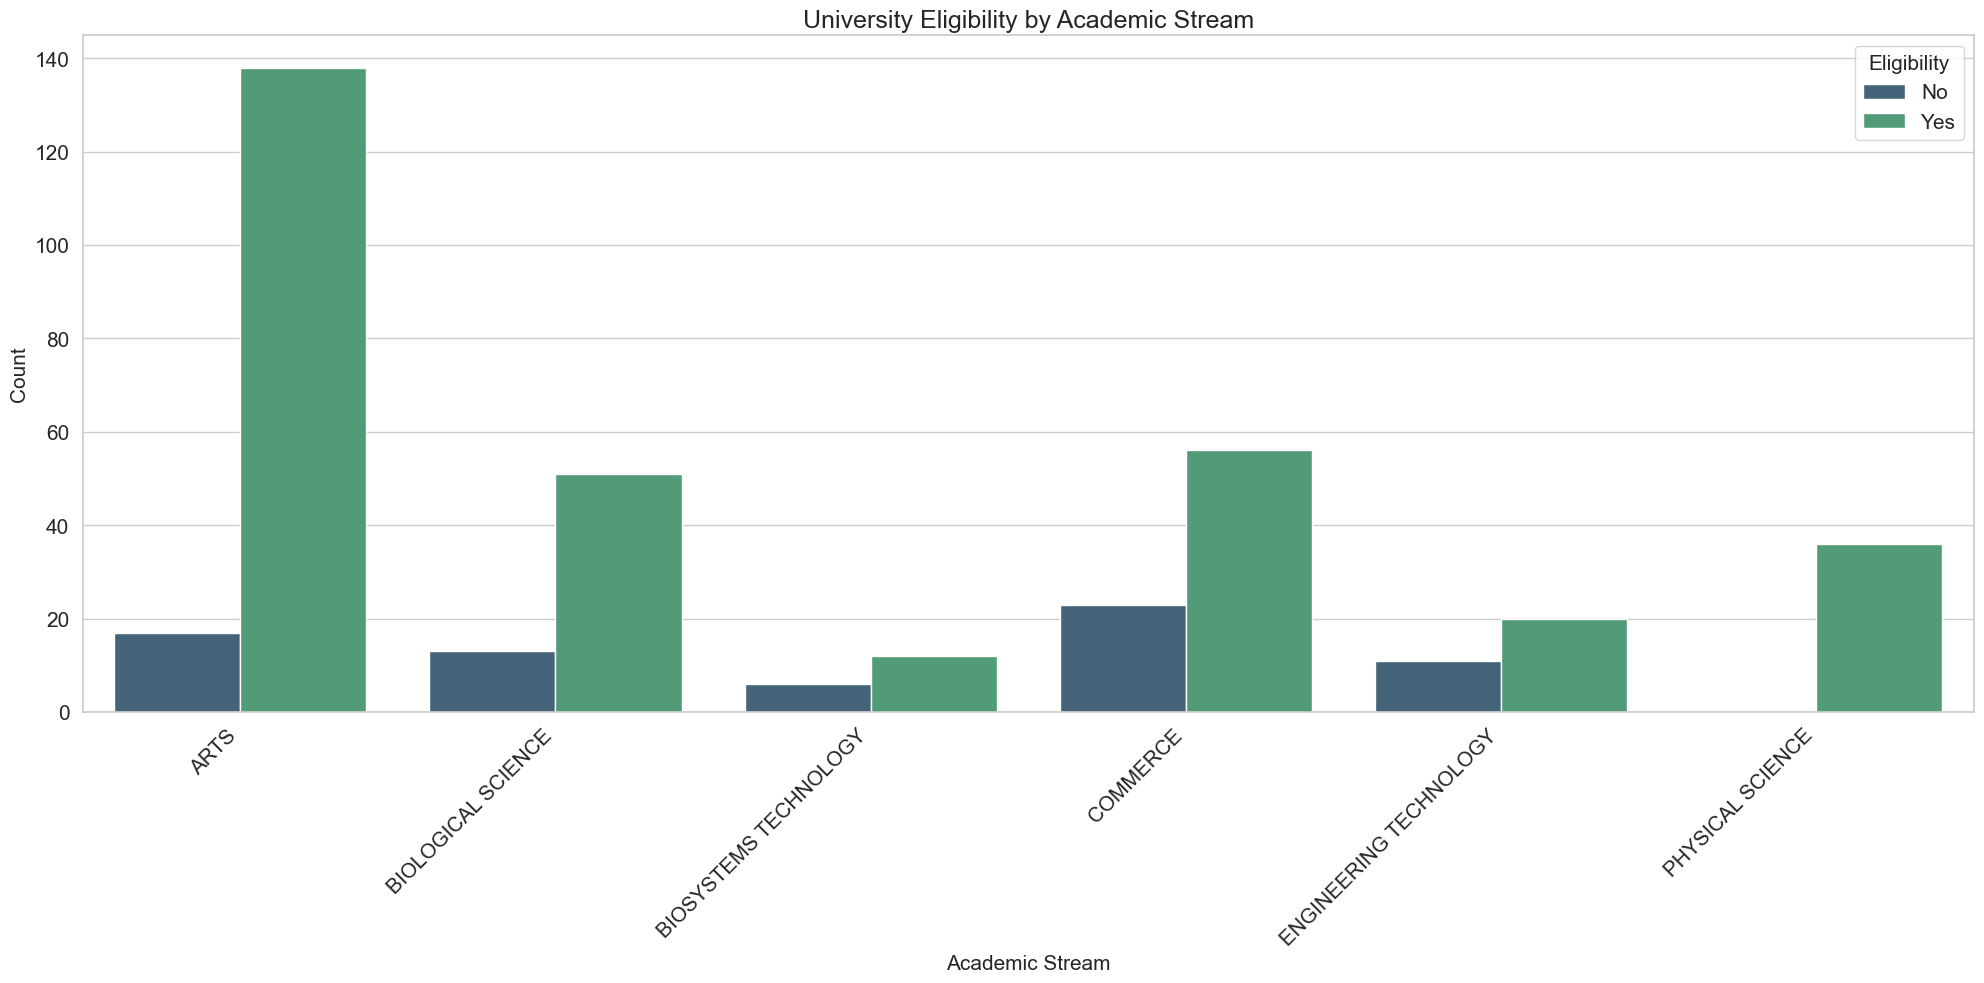

In [49]:
# 3. Count Plot of university_eligible by stream
plt.figure(figsize=(20, 10)) # Increased width for better readability with more categories

# Correct the custom_palette_map to match the actual categories ('No' and 'Yes')
custom_palette_map = {'No': '#3c6682', 'Yes': '#45a778'}
sns.countplot(x='stream', hue='eligible_for_university_entrance', data=df, palette=custom_palette_map)
plt.title('University Eligibility by Academic Stream', fontsize=18)
plt.xlabel('Academic Stream', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.legend(title='Eligibility', title_fontsize=15, fontsize=15)
plt.tight_layout()
plt.show()

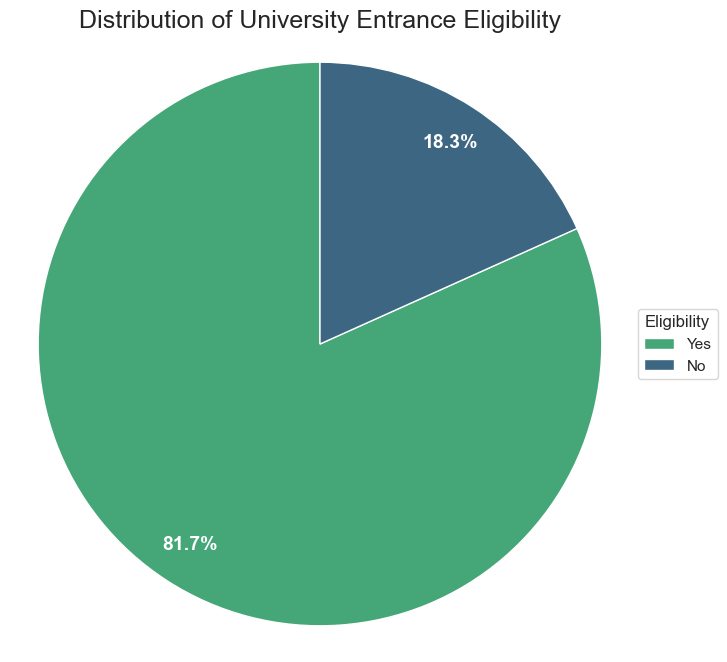

In [50]:


# Calculate value counts and percentages for the pie chart
eligibility_counts = df['eligible_for_university_entrance'].value_counts()
eligibility_percentages = df['eligible_for_university_entrance'].value_counts(normalize=True) * 100

# Define the custom color palette
custom_palette_map = {'No': '#3c6682', 'Yes': '#45a778'}
# Ensure colors are ordered correctly based on the index of eligibility_counts
colors_ordered = [custom_palette_map[label] for label in eligibility_counts.index]

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(eligibility_counts,
        colors=colors_ordered,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85,  # Distance of percentages from the center
        textprops={'color': 'white', 'fontsize': 14, 'fontweight': 'bold'})

plt.title('Distribution of University Entrance Eligibility', fontsize=18)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend
plt.legend(wedges, eligibility_counts.index, title="Eligibility", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

**Objective 1 Analysis**

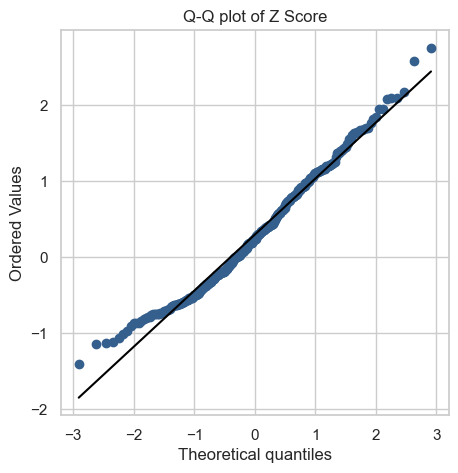

In [51]:
import scipy.stats as stats
import matplotlib.cm as cm
viridis_color = cm.viridis(0.3)
fig, ax = plt.subplots(figsize=(5,5))
stats.probplot(df['Zscore'],plot=ax)
ax.get_lines()[0].set_color(viridis_color)  
ax.get_lines()[1].set_color('black')
plt.title('Q-Q plot of Z Score')
plt.show()

In [52]:
stats.shapiro(df['Zscore'])

ShapiroResult(statistic=np.float64(0.9833013866378124), pvalue=np.float64(0.0002077171996506425))

In [53]:
groups = [group['Zscore'].values 
          for name, group in df.groupby('stream')]

stats.levene(*groups)

LeveneResult(statistic=np.float64(0.9301681506735054), pvalue=np.float64(0.4612776163944048))

In [54]:
from scipy.stats import f_oneway

class ANOVAAnalyzer:
    def __init__(self, df):
        self.df_original = df
        self.df_prepared = None

    def _prepare_data(self):
        # Select relevant columns
        self.df_prepared = self.df_original[['Zscore', 'stream']].copy()

        # Drop rows with missing values
        self.df_prepared.dropna(inplace=True)

        # Ensure 'Zscore' is numeric and 'stream' is categorical
        self.df_prepared['Zscore'] = pd.to_numeric(self.df_prepared['Zscore'], errors='coerce')
        self.df_prepared['stream'] = self.df_prepared['stream'].astype('category')

        # Drop any rows where 'Zscore' might have become NaN after coercion
        self.df_prepared.dropna(subset=['Zscore'], inplace=True)

        return self.df_prepared

    def perform_anova(self):
        if self.df_prepared is None:
            self._prepare_data()

        # Extract Zscore values for each stream, explicitly setting observed=False to suppress FutureWarning
        zscores_by_stream = [group['Zscore'].values for name, group in self.df_prepared.groupby('stream', observed=False)]

        # Perform one-way ANOVA test
        f_statistic, p_value = f_oneway(*zscores_by_stream)

        return f_statistic, p_value

analyzer = ANOVAAnalyzer(df)
f_statistic, p_value = analyzer.perform_anova()

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 4.4862
P-value: 0.0006


In [55]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results_standalone = pairwise_tukeyhsd(endog=analyzer.df_prepared['Zscore'],
                                             groups=analyzer.df_prepared['stream'],
                                             alpha=0.05)

print("\n--- Standalone Tukey HSD Post-Hoc Test Results ---")
print(tukey_results_standalone)
print("--------------------------------------------------")


--- Standalone Tukey HSD Post-Hoc Test Results ---
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                 group2         meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------------
                  ARTS     BIOLOGICAL SCIENCE    0.058 0.9945 -0.2496 0.3656  False
                  ARTS  BIOSYSTEMS TECHNOLOGY  -0.1699 0.9348 -0.6854 0.3456  False
                  ARTS               COMMERCE  -0.2822 0.0557 -0.5684 0.0039  False
                  ARTS ENGINEERING TECHNOLOGY  -0.3412 0.1589 -0.7485 0.0661  False
                  ARTS       PHYSICAL SCIENCE   0.2604 0.3748 -0.1226 0.6434  False
    BIOLOGICAL SCIENCE  BIOSYSTEMS TECHNOLOGY  -0.2278 0.8455 -0.7801 0.3245  False
    BIOLOGICAL SCIENCE               COMMERCE  -0.3402 0.0598 -0.6884 0.0079  False
    BIOLOGICAL SCIENCE ENGINEERING TECHNOLOGY  -0.3992 0.1197 -0.8522 0.0538  False
    BIOLOGICAL SCIENCE  

In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
model = smf.ols('Zscore ~ C(stream)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Zscore   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     4.486
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           0.000553
Time:                        19:05:45   Log-Likelihood:                -416.05
No. Observations:                 383   AIC:                             844.1
Df Residuals:                     377   BIC:                             867.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [57]:
conf_int = model.conf_int()
conf_int.columns = ['Lower CI', 'Upper CI']
print(conf_int)


                                     Lower CI  Upper CI
Intercept                            0.243018  0.471302
C(stream)[T.BIOLOGICAL SCIENCE]     -0.153182  0.269106
C(stream)[T.BIOSYSTEMS TECHNOLOGY]  -0.523721  0.184001
C(stream)[T.COMMERCE]               -0.478689 -0.085799
C(stream)[T.ENGINEERING TECHNOLOGY] -0.620837 -0.061657
C(stream)[T.PHYSICAL SCIENCE]       -0.002484  0.523342


**Objective 2 Analysis**

In [58]:
#Independent Samples T-test (Gender vs Z-score)
male_scores = df[df['gender'] == 'male']['Zscore']
female_scores = df[df['gender'] == 'female']['Zscore']

# Perform Levene's test for equality of variances
stat_v, p_v = stats.levene(male_scores, female_scores)

# T-test (Welch's T-test if variances are unequal)
t_stat, t_p = stats.ttest_ind(male_scores, female_scores, equal_var=(p_v > 0.05))
print(f"T-test Result: t-statistic = {t_stat:.4f}, p-value = {t_p:.4f}")

T-test Result: t-statistic = -3.5707, p-value = 0.0004


In [59]:
#Correlation Analysis (Age vs Z-score)
corr, corr_p = stats.pearsonr(df['age'], df['Zscore'])
print(f"Correlation Result: coefficient = {corr:.4f}, p-value = {corr_p:.4f}")

Correlation Result: coefficient = 0.0244, p-value = 0.6341


In [60]:
#Multiple Linear Regression (Gender and Age as Predictors)

df['gender_encoded'] = df['gender'].map({'male': 0, 'female': 1})

X = df[['age', 'gender_encoded']]
X = sm.add_constant(X)
y = df['Zscore']

model = sm.OLS(y, X).fit()
print("\n--- Multiple Linear Regression Summary ---")
print(model.summary())


--- Multiple Linear Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                 Zscore   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     6.532
Date:                Mon, 02 Feb 2026   Prob (F-statistic):            0.00163
Time:                        19:05:56   Log-Likelihood:                -420.65
No. Observations:                 383   AIC:                             847.3
Df Residuals:                     380   BIC:                             859.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------


In [61]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('final_stratified_sample.csv')

df['gender_encoded'] = df['gender'].map({'male': 0, 'female': 1})

X = df[['gender_encoded']]
X = sm.add_constant(X)
y = df['Zscore']

final_model = sm.OLS(y, X).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Zscore   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     12.75
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           0.000402
Time:                        19:05:57   Log-Likelihood:                -420.82
No. Observations:                 383   AIC:                             845.6
Df Residuals:                     381   BIC:                             853.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1195      0.062      1.

**Objective 3 Analysis**

In [62]:
##perform independent t test
from scipy import stats

# Filter data for 'new' and 'old' syllabus
new_syllabus_zscore = df[df['syllabus'] == 'new']['Zscore'].dropna()
old_syllabus_zscore = df[df['syllabus'] == 'old']['Zscore'].dropna()

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(new_syllabus_zscore, old_syllabus_zscore)

print(f"Independent t-test for Zscore (New vs. Old Syllabus):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print(f"There is a statistically significant difference in Zscore between new and old syllabus.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print(f"There is no statistically significant difference in Zscore between new and old syllabus.")

Independent t-test for Zscore (New vs. Old Syllabus):
T-statistic: -0.9856
P-value: 0.3249
Since the p-value (0.3249) is greater than alpha (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in Zscore between new and old syllabus.


In [63]:
##pearson correlation analysis
from scipy import stats

# Remove rows where 'cgt_r' is 'Absent'
df_cleaned = df[df['cgt_r'] != 'Absent'].copy()

# Convert 'cgt_r' to numeric
df_cleaned['cgt_r'] = pd.to_numeric(df_cleaned['cgt_r'])

# Perform Pearson correlation and get p-value
r_value, p_value = stats.pearsonr(df_cleaned['cgt_r'], df_cleaned['Zscore'])

print(f"Pearson Correlation between CGT_R and Zscore (excluding 'Absent' values): r = {r_value:.4f}, p = {p_value:.4f}")


Pearson Correlation between CGT_R and Zscore (excluding 'Absent' values): r = 0.3070, p = 0.0000


In [64]:
#Fitting a multiple linear regression model
import pandas as pd
import statsmodels.api as sm
from scipy import stats


df['cgt_r'] = pd.to_numeric(df['cgt_r'], errors='coerce').fillna(0)
df['is_new_syllabus'] = (df['syllabus'] == 'new').astype(int)

X = df[['cgt_r', 'is_new_syllabus']]
X = sm.add_constant(X)
y = df['Zscore']

objective_model = sm.OLS(y, X).fit()
print("\n--- Regression Summary ---")
print(objective_model.summary())


--- Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                 Zscore   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.813
Date:                Mon, 02 Feb 2026   Prob (F-statistic):              0.165
Time:                        19:06:01   Log-Likelihood:                -425.30
No. Observations:                 383   AIC:                             856.6
Df Residuals:                     380   BIC:                             868.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const         

**Objective 4 Analysis**

In [65]:
from scipy.stats import chi2_contingency
import pandas as pd # Import pandas if not already imported

df['eligible_for_university_entrance'] = df.apply(lambda row: 'No' if 'F' in [row['sub1_r'], row['sub2_r'], row['sub3_r']] else 'Yes', axis=1)
display(df.head())

# Create the contingency table for gender and eligibility
contingency_table_gender = pd.crosstab(df['gender'], df['eligible_for_university_entrance'])

# Calculate expected frequencies for gender contingency table
chi2_gender, p_value_gender, dof_gender, expected_gender = chi2_contingency(contingency_table_gender)

print("Expected Frequencies (Gender vs. Eligibility):")
print(expected_gender.round(2))

# Re-print Chi-squared test results for completeness
print(f"\nChi-squared statistic (Gender): {chi2_gender:.4f}")
print(f"P-value (Gender): {p_value_gender:.4f}")

,index,stream,Zscore,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender,is_new_syllabus,eligible_for_university_entrance
0,197401,ARTS,-0.5977,2020,POLITICAL SCIENCE,F,BUDDHIST CIVILIZATION,S,SINHALA,S,36.0,F,new,16,August,1989,male,1,No
1,117518,ARTS,0.5419,2020,POLITICAL SCIENCE,C,BUDDHIST CIVILIZATION,C,SINHALA,B,44.0,F,new,12,March,2001,female,1,Yes
2,136408,ARTS,1.1139,2020,GEOGRAPHY,B,POLITICAL SCIENCE,B,ARABIC,A,48.0,C,new,31,October,2000,female,1,Yes
3,250135,ARTS,-0.5008,2020,GEOGRAPHY,S,ART,S,SINHALA,S,32.0,F,new,12,January,2002,male,1,Yes
4,193614,ARTS,0.3237,2020,GEOGRAPHY,S,COMMUNICATION & MEDIA STUDIES,C,SINHALA,C,34.0,F,new,24,July,2000,female,1,Yes


Expected Frequencies (Gender vs. Eligibility):
[[ 44.96 201.04]
 [ 25.04 111.96]]

Chi-squared statistic (Gender): 9.9938
P-value (Gender): 0.0016


In [66]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create the contingency table for syllabus and eligibility
contingency_table_syllabus = pd.crosstab(df['syllabus'], df['eligible_for_university_entrance'])

# Calculate expected frequencies for syllabus contingency table
chi2_syllabus, p_value_syllabus, dof_syllabus, expected_syllabus = chi2_contingency(contingency_table_syllabus)

print("Expected Frequencies (Syllabus vs. Eligibility):")
print(expected_syllabus.round(2))

# Re-print Chi-squared test results for completeness
print(f"\nChi-squared statistic (Syllabus): {chi2_syllabus:.4f}")
print(f"P-value (Syllabus): {p_value_syllabus:.4f}")

Expected Frequencies (Syllabus vs. Eligibility):
[[ 65.43 292.57]
 [  4.57  20.43]]

Chi-squared statistic (Syllabus): 0.3275
P-value (Syllabus): 0.5671


In [67]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create the contingency table for stream and eligibility
contingency_table_stream = pd.crosstab(df['stream'], df['eligible_for_university_entrance'])

# Calculate expected frequencies for stream contingency table
chi2_stream, p_value_stream, dof_stream, expected_stream = chi2_contingency(contingency_table_stream)

print("Expected Frequencies (Stream vs. Eligibility):")
print(expected_stream.round(2))

# Re-print Chi-squared test results for completeness
print(f"\nChi-squared statistic (Stream): {chi2_stream:.4f}")
print(f"P-value (Stream): {p_value_stream:.4f}")

Expected Frequencies (Stream vs. Eligibility):
[[ 28.33 126.67]
 [ 11.7   52.3 ]
 [  3.29  14.71]
 [ 14.44  64.56]
 [  5.67  25.33]
 [  6.58  29.42]]

Chi-squared statistic (Stream): 28.8614
P-value (Stream): 0.0000


In [68]:
#logistic model for objective 4
import statsmodels.api as sm
import pandas as pd

# Re-create 'eligible_for_university_entrance' as 0/1 to ensure consistency
df['eligible_for_university_entrance'] = df.apply(lambda row: 0 if 'F' in [row['sub1_r'], row['sub2_r'], row['sub3_r']] else 1, axis=1)
df['age'] = df['al_year'] - df['birth_year']
# Re-apply stream grouping to ensure consistency with the latest logic
df['stream_grouped'] = df['stream'].replace({
    'BIOLOGICAL SCIENCE': 'Science',
    'PHYSICAL SCIENCE': 'Science'
})

# Select relevant columns for the model
model_df = df[['eligible_for_university_entrance', 'gender', 'syllabus', 'stream_grouped', 'age']].dropna()

# Define the dependent variable (y). It should now be 0/1 because of the re-creation above.
y = model_df['eligible_for_university_entrance']

# Create dummy variables for categorical features
X = pd.get_dummies(
    model_df[['gender', 'syllabus', 'stream_grouped']],
    drop_first=True # Drop the first category to avoid multicollinearity
)

# Add the 'age' column to the features DataFrame
X['age'] = model_df['age']

# Add a constant (intercept) to the features DataFrame
X = sm.add_constant(X)

# Ensure all columns in X are numeric
X = X.astype(int)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.442009
         Iterations 6
                                  Logit Regression Results                                  
Dep. Variable:     eligible_for_university_entrance   No. Observations:                  383
Model:                                        Logit   Df Residuals:                      375
Method:                                         MLE   Df Model:                            7
Date:                              Mon, 02 Feb 2026   Pseudo R-squ.:                 0.07056
Time:                                      19:06:10   Log-Likelihood:                -169.29
converged:                                     True   LL-Null:                       -182.14
Covariance Type:                          nonrobust   LLR p-value:                 0.0005690
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [69]:
# logistic model for objective 4 after removing the insignificant variables
# Select relevant columns for the model
model_df = df[['eligible_for_university_entrance', 'gender', 'stream_grouped']].dropna()

# Define the dependent variable (y). It should now be 0/1 because of the re-creation above.
y = model_df['eligible_for_university_entrance']

# Create dummy variables for categorical features
X = pd.get_dummies(
    model_df[['gender', 'stream_grouped']],
    drop_first=True) # Drop the first category to avoid multicollinearit

# Add a constant (intercept) to the features DataFrame
X = sm.add_constant(X)

# Ensure all columns in X are numeric
X = X.astype(int)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.442281
         Iterations 6
                                  Logit Regression Results                                  
Dep. Variable:     eligible_for_university_entrance   No. Observations:                  383
Model:                                        Logit   Df Residuals:                      377
Method:                                         MLE   Df Model:                            5
Date:                              Mon, 02 Feb 2026   Pseudo R-squ.:                 0.06999
Time:                                      19:06:10   Log-Likelihood:                -169.39
converged:                                     True   LL-Null:                       -182.14
Covariance Type:                          nonrobust   LLR p-value:                 0.0001118
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load data
df = pd.read_csv('final_stratified_sample.csv')

# 2. FEATURE ENGINEERING
df['age'] = df['al_year'] - df['birth_year']

# 3. Preprocessing
grade_map = {'A': 5, 'B': 4, 'C': 3, 'S': 2, 'F': 1, 'Absent': 0}
grade_cols = ['sub1_r', 'sub2_r', 'sub3_r', 'ge_r']
for col in grade_cols:
    df[col] = df[col].map(grade_map)

df['cgt_r'] = pd.to_numeric(df['cgt_r'], errors='coerce').fillna(0)
df['gender'] = df['gender'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['stream', 'syllabus'], drop_first=True)

# 4. Define Features
features = ['sub1_r', 'sub2_r', 'sub3_r', 'ge_r', 'cgt_r', 'gender', 'age'] + \
           [col for col in df.columns if 'stream_' in col or 'syllabus_' in col]

X = df[features]
y = df['Zscore']

# 5. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Define Exact Parameter Grids for GridSearchCV
# Grid Search will try EVERY combination in these lists
model_configs = {
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20],
            "max_features": ['sqrt', None]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 7, 11],
            "weights": ['uniform', 'distance']
        }
    }
}

# 7. Training and Evaluation with GridSearchCV
results = []

for name, config in model_configs.items():
    print(f"Grid Searching {name}...")
    
    # Selection of scaled vs unscaled data
    X_tr = X_train_scaled if name in ["KNN", "Ridge Regression"] else X_train
    X_te = X_test_scaled if name in ["KNN", "Ridge Regression"] else X_test

    # GridSearchCV checks every combination
    grid_search = GridSearchCV(
        config["model"], 
        config["params"], 
        cv=3, 
        scoring='r2', 
        n_jobs=-1
    )
    
    grid_search.fit(X_tr, y_train)
    best_model = grid_search.best_estimator_
    preds = best_model.predict(X_te)

    # Calculate Metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    hit_rate = np.mean(np.abs(y_test - preds) < 0.2)

    results.append({
        "Model": name,
        "Best Parameters": grid_search.best_params_,
        "Accuracy (R2)": f"{r2*100:.2f}%",
        "Precision (MAE)": round(mae, 4),
        "Hit Rate (±0.2)": f"{hit_rate*100:.2f}%"
    })

# 8. Display Final Results
results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None) # To see full parameter strings
print("\n--- Exhaustive Grid Search Results ---")
print(results_df[['Model', 'Accuracy (R2)', 'Precision (MAE)', 'Hit Rate (±0.2)']])

# To see the winning settings for each model:
print("\n--- Winning Parameters ---")
for i, row in results_df.iterrows():
    print(f"{row['Model']}: {row['Best Parameters']}")

Grid Searching Ridge Regression...
Grid Searching Decision Tree...
Grid Searching Random Forest...
Grid Searching Gradient Boosting...
Grid Searching KNN...

--- Exhaustive Grid Search Results ---
               Model Accuracy (R2)  Precision (MAE) Hit Rate (±0.2)
0   Ridge Regression        92.19%           0.1644          71.43%
1      Decision Tree        82.46%           0.2534          46.75%
2      Random Forest        91.13%           0.1833          59.74%
3  Gradient Boosting        92.96%           0.1638          64.94%
4                KNN        84.10%           0.2521          44.16%

--- Winning Parameters ---
Ridge Regression: {'alpha': 1.0}
Decision Tree: {'max_depth': 5, 'min_samples_split': 2}
Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
KNN: {'n_neighbors': 3, 'weights': 'distance'}


In [71]:
# 1. Extract the Ridge model from our results list
# We look through the results we stored to find the one named 'Ridge Regression'
ridge_entry = next(item for item in results if item["Model"] == "Ridge Regression")
best_params = ridge_entry["Best Parameters"]

# 2. Re-fit just the Ridge model with those best parameters
# (We do this to ensure we are looking at the exact winning version)
final_ridge = Ridge(**best_params)
final_ridge.fit(X_train_scaled, y_train) # Use scaled data for Ridge

# 3. Create the Importance Table
importance = pd.DataFrame({
    'Feature': features,
    'Weight': final_ridge.coef_
})

# 4. Sort and Display
importance = importance.sort_values(by='Weight', ascending=False)

print("\n--- Feature Weights (Impact on Z-Score) ---")
print(importance.to_string(index=False))


--- Feature Weights (Impact on Z-Score) ---
                      Feature    Weight
                       sub3_r  0.299151
                       sub2_r  0.290487
                       sub1_r  0.269447
    stream_BIOLOGICAL SCIENCE  0.160455
stream_ENGINEERING TECHNOLOGY  0.123279
      stream_PHYSICAL SCIENCE  0.115587
 stream_BIOSYSTEMS TECHNOLOGY  0.088962
                         ge_r  0.031036
              stream_COMMERCE  0.026934
                       gender -0.001667
                        cgt_r -0.018248
                 syllabus_old -0.032990
                          age -0.033352


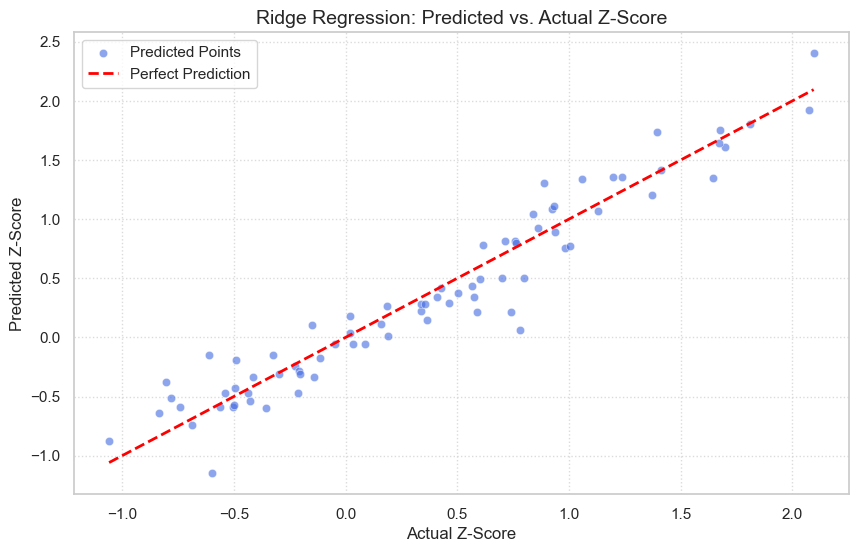

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions using the best Ridge model
# Make sure to use the scaled test data
y_pred = final_ridge.predict(X_test_scaled)

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='royalblue', label='Predicted Points')

# 3. Add the "Perfect Prediction" line (Diagonal)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 4. Formatting
plt.title('Ridge Regression: Predicted vs. Actual Z-Score', fontsize=14)
plt.xlabel('Actual Z-Score', fontsize=12)
plt.ylabel('Predicted Z-Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()